In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Part 1: Beta-Binomial Conjugacy — The Math

**Prior:** θ ~ Beta(α_prior, β_prior)
**Likelihood:** X | θ ~ Binomial(N, θ)

By Bayes' theorem:
p(θ | X) ∝ θ^X (1-θ)^(N-X) · θ^(α_prior - 1)(1-θ)^(β_prior - 1)
         ∝ θ^(α_prior + X - 1) (1-θ)^(β_prior + N - X - 1)

This is a Beta distribution, so the posterior is:

    α_post = α_prior + X          (X = number of clicks)
    β_post = β_prior + (N - X)    (N - X = number of non-clicks)

The Beta prior acts as "pseudo-observations":
α_prior = virtual prior clicks, β_prior = virtual prior non-clicks.

In [2]:
# True CTR and data generation
theta_true = 0.25
N_total = 500
observations = np.random.binomial(1, theta_true, N_total)

print(f"True CTR:        {theta_true}")
print(f"Total clicks:    {observations.sum()}")
print(f"Empirical CTR:   {observations.mean():.4f}")

True CTR:        0.25
Total clicks:    131
Empirical CTR:   0.2620


In [3]:
def beta_posterior(alpha_prior, beta_prior, clicks, non_clicks):
    """
    Returns Beta posterior hyperparameters given:
      - Beta(alpha_prior, beta_prior) prior
      - Binomial likelihood with 'clicks' successes and 'non_clicks' failures
    """
    alpha_post = alpha_prior + clicks
    beta_post  = beta_prior  + non_clicks
    return alpha_post, beta_post


def normalized_likelihood(theta_grid, clicks, non_clicks):
    """
    Computes the Binomial likelihood L(θ) = θ^clicks * (1-θ)^non_clicks
    normalized to integrate to 1 over theta_grid (for visual comparison).
    """
    N = clicks + non_clicks
    if N == 0:
        return np.ones_like(theta_grid) / len(theta_grid)
    likelihood = (theta_grid ** clicks) * ((1 - theta_grid) ** non_clicks)
    area = np.trapz(likelihood, theta_grid)
    if area > 0:
        likelihood = likelihood / area
    return likelihood

print("Helper functions defined.")

Helper functions defined.


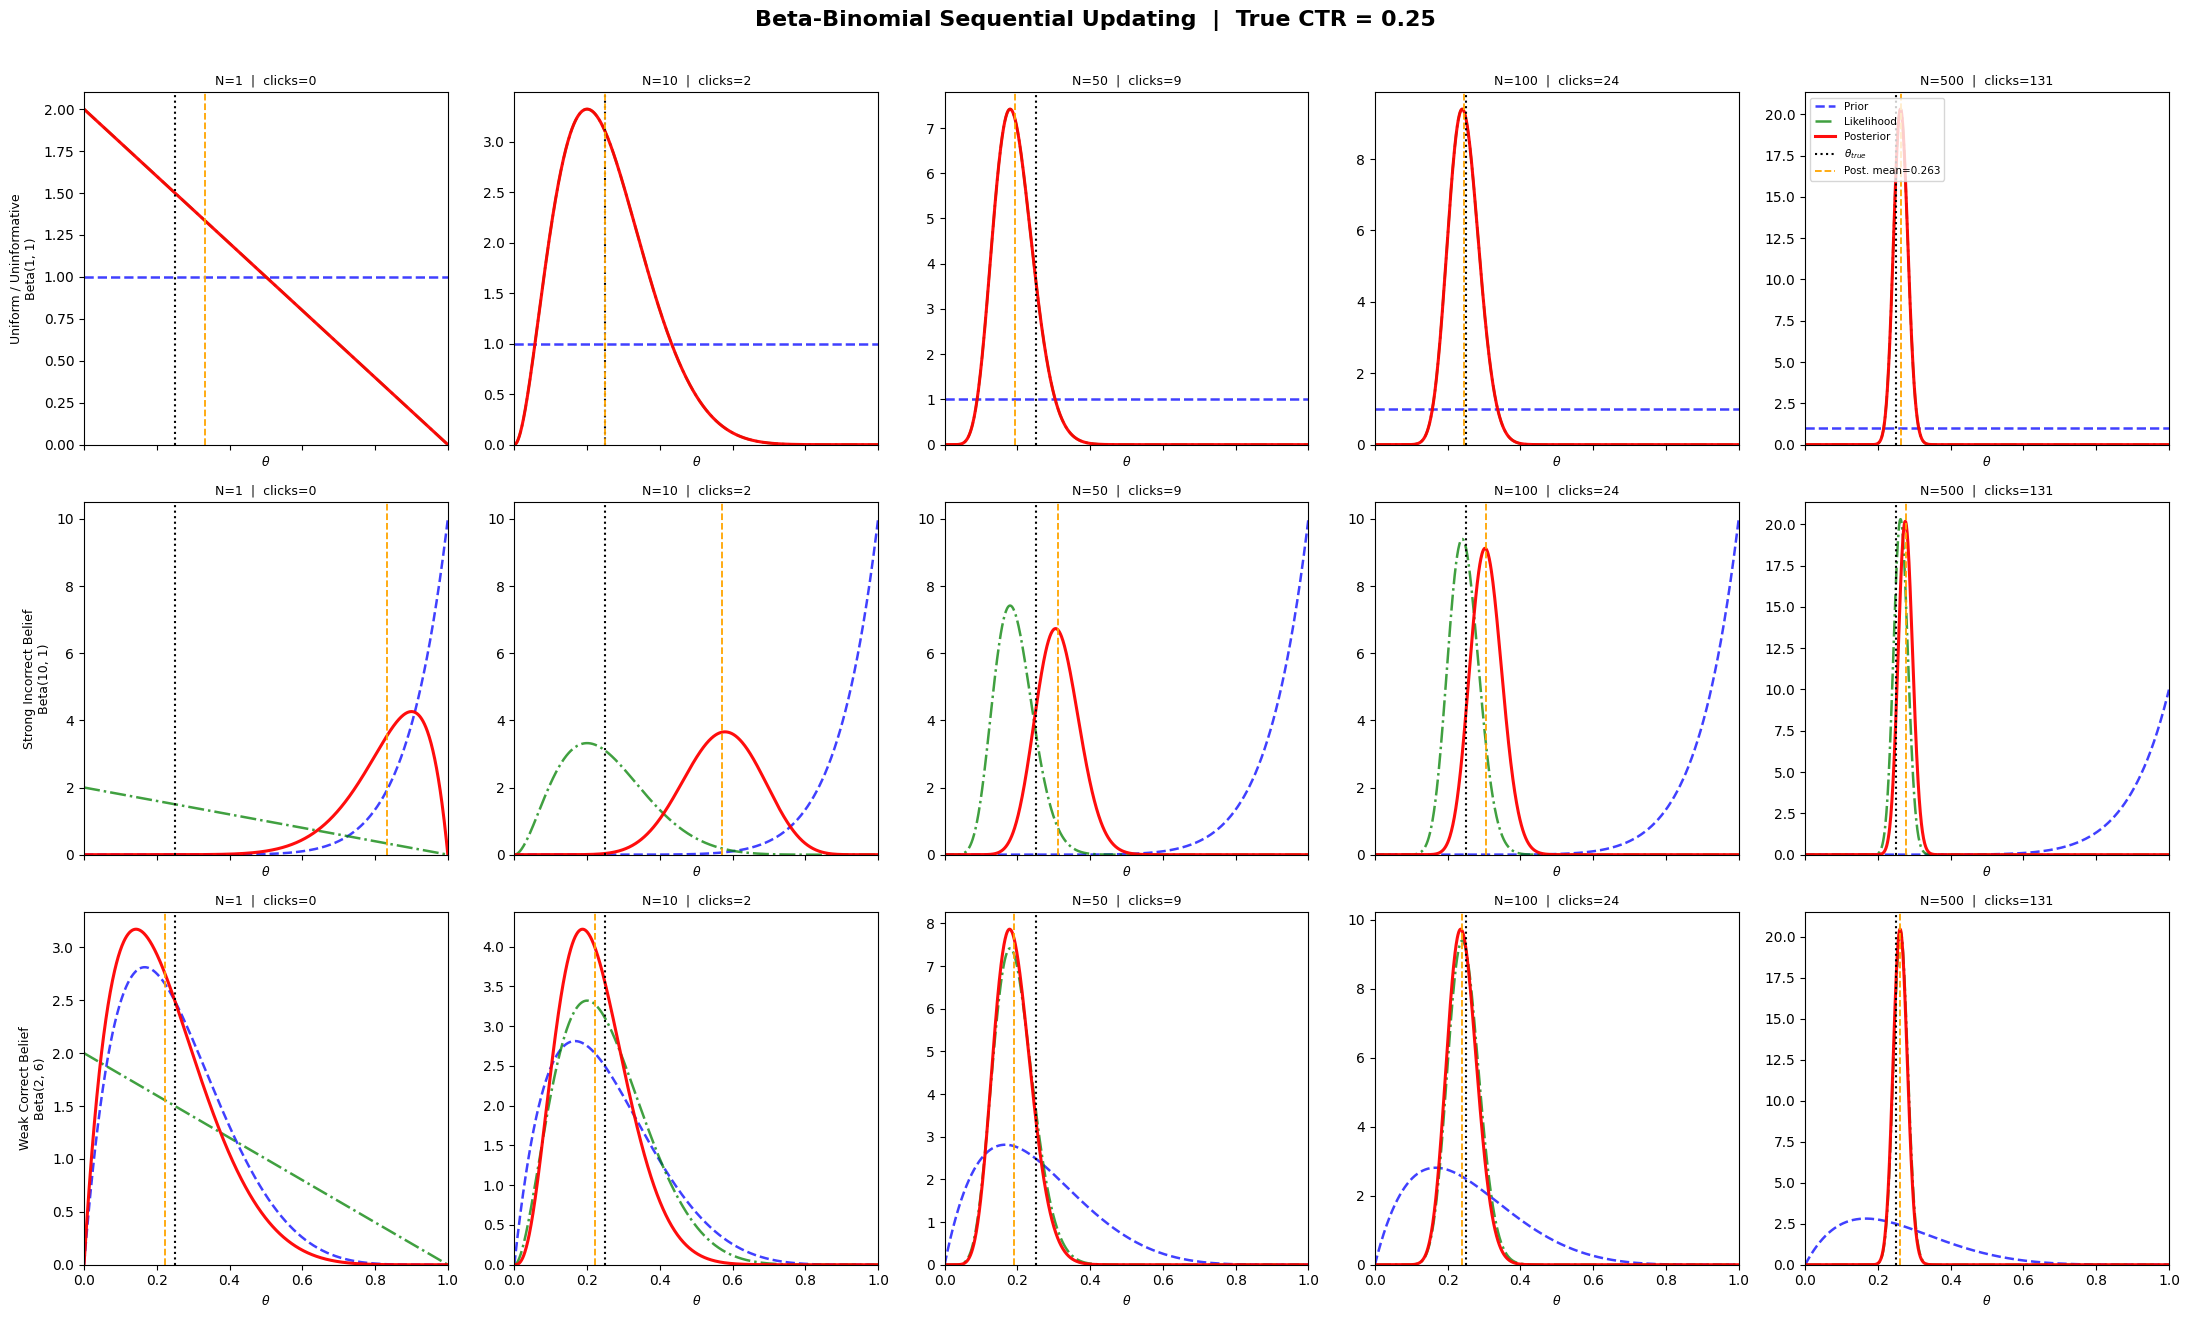

In [4]:
# Three priors: (alpha, beta)
priors = {
    'Uniform / Uninformative\nBeta(1, 1)' : (1,  1),
    'Strong Incorrect Belief\nBeta(10, 1)': (10, 1),
    'Weak Correct Belief\nBeta(2, 6)'     : (2,  6),
}

N_steps    = [1, 10, 50, 100, 500]
theta_grid = np.linspace(1e-4, 1 - 1e-4, 1000)

fig, axes = plt.subplots(
    nrows=len(priors),
    ncols=len(N_steps),
    figsize=(22, 13),
    sharex=True
)
fig.suptitle(
    f'Beta-Binomial Sequential Updating  |  True CTR = {theta_true}',
    fontsize=16, fontweight='bold', y=1.01
)

for row_idx, (prior_label, (a0, b0)) in enumerate(priors.items()):
    for col_idx, N in enumerate(N_steps):
        ax = axes[row_idx][col_idx]

        # Accumulate data up to N observations
        data_so_far       = observations[:N]
        clicks_so_far     = int(data_so_far.sum())
        non_clicks_so_far = N - clicks_so_far

        # Prior PDF
        prior_pdf = stats.beta.pdf(theta_grid, a0, b0)

        # Posterior hyperparameters and PDF
        a_post, b_post = beta_posterior(a0, b0, clicks_so_far, non_clicks_so_far)
        posterior_pdf  = stats.beta.pdf(theta_grid, a_post, b_post)

        # Normalized likelihood
        lik = normalized_likelihood(theta_grid, clicks_so_far, non_clicks_so_far)

        # Plot all three curves
        ax.plot(theta_grid, prior_pdf,  'b--', lw=1.8, label='Prior',      alpha=0.75)
        ax.plot(theta_grid, lik,        'g-.', lw=1.8, label='Likelihood', alpha=0.75)
        ax.plot(theta_grid, posterior_pdf, 'r-', lw=2.2, label='Posterior', alpha=0.95)

        # True CTR and posterior mean markers
        ax.axvline(theta_true, color='black',  lw=1.5, linestyle=':',  label=r'$\theta_{true}$')
        post_mean = a_post / (a_post + b_post)
        ax.axvline(post_mean,  color='orange', lw=1.3, linestyle='--',
                   label=f'Post. mean={post_mean:.3f}')

        ax.set_title(f'N={N}  |  clicks={clicks_so_far}', fontsize=9)
        ax.set_xlabel(r'$\theta$', fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(bottom=0)

        # Row label (prior name) on leftmost column
        if col_idx == 0:
            ax.set_ylabel(prior_label, fontsize=9)

        # Legend only on top-right cell
        if row_idx == 0 and col_idx == len(N_steps) - 1:
            ax.legend(fontsize=7.5, loc='upper left')

plt.tight_layout()
plt.show()

## Observations — Part 1

1. **Uniform Prior Beta(1,1):** No prior bias. The posterior tracks the
   likelihood from the start and converges smoothly to θ = 0.25.

2. **Strong Incorrect Prior Beta(10,1):** Prior mean ≈ 0.91 — far from the
   truth. At small N the posterior is badly biased. By N=500 the data has
   largely corrected it, but convergence is slower than the uninformative case.
   This shows the "cost" of a strong, wrong prior.

3. **Weak Correct Prior Beta(2,6):** Prior mean = 2/8 = 0.25, matching the
   true CTR. Even at small N the posterior is already near the truth; more
   data only sharpens (narrows) it.

4. **General trend:** All three posteriors converge to the same narrow
   distribution centred near θ_true = 0.25 as N → 500. The likelihood
   dominates the prior for large N — Bayesian consistency.

5. **Pseudo-observation interpretation:** α_prior and β_prior act like
   "virtual" prior clicks and non-clicks. A Beta(10,1) prior is like having
   already seen 10 clicks and 1 non-click before the experiment begins,
   which is why it takes so much real data to overcome.

## Part 2: Gaussian-Gaussian Conjugacy (Sensor Data)

**Model:**
- Known sensor noise variance: σ² = 5.0
- Unknown true mean temperature: μ
- Prior: μ ~ N(μ₀, σ₀²)  →  we use μ₀ = 20, σ₀² = 10
- Likelihood: xᵢ | μ ~ N(μ, σ²)

**Closed-Form Sequential Update Equations:**

Posterior variance:
    1/σ_N² = 1/σ₀² + N/σ²   →   σ_N² = (σ₀² · σ²) / (N·σ₀² + σ²)

Posterior mean:
    μ_N = σ_N² · (μ₀/σ₀² + N·x̄_N/σ²)

For large N:  σ_N² ≈ σ²/N  →  uncertainty shrinks at rate O(1/N)

In [5]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Known parameters
sigma2   = 5.0    # known sensor noise variance
mu_true  = 22.5   # true mean temperature (unknown to the model)
N_data   = 100    # number of observations

# Prior hyperparameters
mu_0     = 20.0   # prior mean
sigma2_0 = 10.0   # prior variance

# Generate 100 data points from N(mu_true, sigma2)
data = np.random.normal(mu_true, np.sqrt(sigma2), N_data)

print(f"True mean (mu_true):          {mu_true}")
print(f"Sample mean of data:          {data.mean():.4f}")
print(f"Sample std of data:           {data.std():.4f}")
print(f"Prior: N(mu_0={mu_0}, sigma2_0={sigma2_0})")

True mean (mu_true):          22.5
Sample mean of data:          22.2678
Sample std of data:           2.0205
Prior: N(mu_0=20.0, sigma2_0=10.0)


In [6]:
def gaussian_posterior(mu_0, sigma2_0, sigma2, data_subset):
    """
    Computes the Gaussian posterior mean and variance.

    Given:
      - Prior:      μ ~ N(mu_0, sigma2_0)
      - Likelihood: xᵢ ~ N(μ, sigma2)   [sigma2 known]
      - Data:       data_subset (array of N observations)

    Returns:
      mu_N     : posterior mean
      sigma2_N : posterior variance
    """
    N = len(data_subset)
    if N == 0:
        return mu_0, sigma2_0

    x_bar    = data_subset.mean()
    sigma2_N = 1.0 / (1.0/sigma2_0 + N/sigma2)
    mu_N     = sigma2_N * (mu_0/sigma2_0 + N*x_bar/sigma2)
    return mu_N, sigma2_N


# Quick sanity check
mu_final, sigma2_final = gaussian_posterior(mu_0, sigma2_0, sigma2, data)
print(f"Posterior mean  after {N_data} obs: {mu_final:.4f}")
print(f"Posterior variance after {N_data} obs: {sigma2_final:.6f}")

Posterior mean  after 100 obs: 22.2565
Posterior variance after 100 obs: 0.049751


In [7]:
step_indices  = list(range(1, N_data + 1))
mu_N_list     = []
sigma2_N_list = []

for n in step_indices:
    mu_n, sigma2_n = gaussian_posterior(mu_0, sigma2_0, sigma2, data[:n])
    mu_N_list.append(mu_n)
    sigma2_N_list.append(sigma2_n)

mu_N_arr     = np.array(mu_N_list)
sigma2_N_arr = np.array(sigma2_N_list)

print("Sequential updates done.")
print(f"Final posterior mean:     {mu_N_arr[-1]:.4f}")
print(f"Final posterior variance: {sigma2_N_arr[-1]:.6f}")

Sequential updates done.
Final posterior mean:     22.2565
Final posterior variance: 0.049751


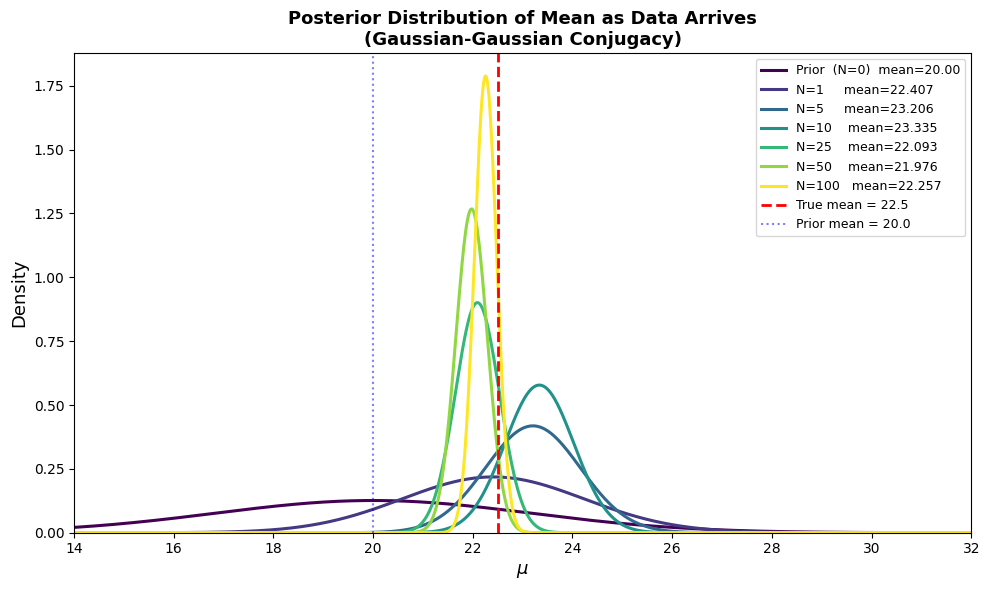

In [8]:
plot_steps = [0, 1, 5, 10, 25, 50, 100]
mu_grid    = np.linspace(14, 32, 1000)
colors     = plt.cm.viridis(np.linspace(0, 1, len(plot_steps)))

fig, ax = plt.subplots(figsize=(10, 6))

for idx, n in enumerate(plot_steps):
    if n == 0:
        mu_n, sigma2_n = mu_0, sigma2_0
        label = f'Prior  (N=0)  mean={mu_n:.2f}'
    else:
        mu_n, sigma2_n = gaussian_posterior(mu_0, sigma2_0, sigma2, data[:n])
        label = f'N={n:<4}  mean={mu_n:.3f}'

    pdf = norm.pdf(mu_grid, mu_n, np.sqrt(sigma2_n))
    ax.plot(mu_grid, pdf, color=colors[idx], lw=2.2, label=label)

ax.axvline(mu_true, color='red',  lw=2,   linestyle='--', label=f'True mean = {mu_true}')
ax.axvline(mu_0,    color='blue', lw=1.5, linestyle=':',  alpha=0.5, label=f'Prior mean = {mu_0}')

ax.set_xlabel(r'$\mu$', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Posterior Distribution of Mean as Data Arrives\n(Gaussian-Gaussian Conjugacy)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(14, 32)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

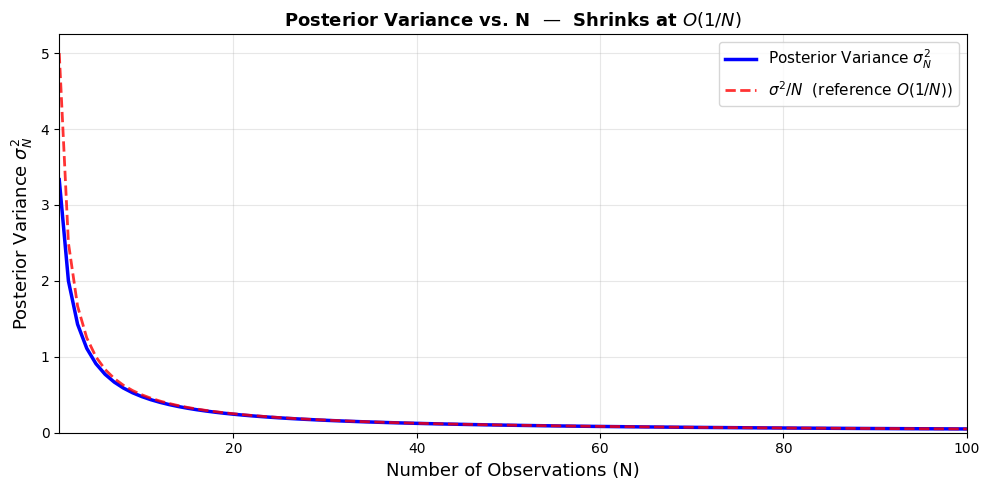

In [9]:
N_arr    = np.array(step_indices)
ref_1_N  = sigma2 / N_arr     # theoretical O(1/N) reference line

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(N_arr, sigma2_N_arr, 'b-',  lw=2.5, label=r'Posterior Variance $\sigma_N^2$')
ax.plot(N_arr, ref_1_N,      'r--', lw=2.0, alpha=0.8,
        label=r'$\sigma^2 / N$  (reference $O(1/N)$)')

ax.set_xlabel('Number of Observations (N)', fontsize=13)
ax.set_ylabel(r'Posterior Variance $\sigma_N^2$', fontsize=13)
ax.set_title(r'Posterior Variance vs. N  —  Shrinks at $O(1/N)$',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(1, N_data)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observations — Part 2

1. **Prior → Posterior shift:** Prior mean was 20.0 but true mean is 22.5.
   As data accumulates the posterior mean is pulled toward 22.5, arriving
   there after roughly 50 observations.

2. **Posterior sharpens:** The PDF becomes increasingly narrow with more data,
   reflecting reduced uncertainty about μ.

3. **O(1/N) convergence:** The variance plot confirms σ_N² ≈ σ²/N for large N.
   The posterior variance curve closely tracks the σ²/N reference line —
   visually proving the O(1/N) rate.

4. **Prior precision as virtual data:** The formula
       1/σ_N² = 1/σ₀² + N/σ²
   shows the prior contributes a fixed "virtual precision" 1/σ₀².
   For large N, the data precision N/σ² dominates and the prior is forgotten.

5. **Posterior mean as weighted average:** μ_N is a precision-weighted
   interpolation between the prior mean μ₀ and the sample mean x̄.
   When σ₀² is large (weak prior), μ_N ≈ x̄. When σ₀² is small
   (strong prior), μ_N is pulled toward μ₀.

## Part 3: The "Why Conjugacy?" Experiment (Numerical Integration)

**Idea:** Repeat the 1D Gaussian experiment but use a Bimodal Prior
(mixture of two Gaussians) — which is strictly non-conjugate.

**Bimodal Prior:**
    p(μ) = 0.5 · N(μ; 18, 1) + 0.5 · N(μ; 27, 1)

Since there is no closed-form posterior, we use Grid Approximation:
  1. Discretize μ over 1,000 grid points
  2. Evaluate prior(μ) × likelihood(data | μ) at each grid point
  3. Normalize to get the posterior

We then compare execution time and memory usage of:
  - Grid Approximation (bimodal prior)  vs.
  - Closed-Form Conjugate Update (Gaussian prior)
for N = 1000 data points.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time
import tracemalloc

np.random.seed(42)

# Reuse parameters from Part 2
sigma2  = 5.0
mu_true = 22.5
mu_0    = 20.0
sigma2_0 = 10.0

# Grid of 1000 points
n_grid     = 1000
mu_grid    = np.linspace(10, 35, n_grid)


def bimodal_prior(mu_grid):
    """
    Non-conjugate bimodal prior:
    p(μ) = 0.5 * N(μ; 18, 1) + 0.5 * N(μ; 27, 1)
    """
    return 0.5 * norm.pdf(mu_grid, 18, 1) + 0.5 * norm.pdf(mu_grid, 27, 1)


def grid_posterior(mu_grid, prior_func, data_arr, sigma2_likelihood):
    """
    Grid Approximation of the posterior.

    Steps:
      1. Compute log prior at each grid point
      2. Compute log likelihood = sum of Gaussian log-likelihoods
         for each data point (log-sum trick for numerical stability)
      3. Add log prior + log likelihood, exponentiate, normalize

    Returns:
      posterior : normalized posterior array over mu_grid
    """
    log_prior = np.log(prior_func(mu_grid) + 1e-300)

    # Sum log-likelihoods across all data points
    log_likelihood = np.zeros(len(mu_grid))
    for x in data_arr:
        log_likelihood += norm.logpdf(x, mu_grid, np.sqrt(sigma2_likelihood))

    log_unnorm = log_prior + log_likelihood
    log_unnorm -= log_unnorm.max()          # subtract max for numerical stability
    unnorm     = np.exp(log_unnorm)

    # Normalize using trapezoidal integration
    posterior = unnorm / np.trapz(unnorm, mu_grid)
    return posterior


print("Bimodal prior and grid approximation functions defined.")

Bimodal prior and grid approximation functions defined.


In [11]:
# 100 points for plotting, 1000 points for benchmarking
data_100  = np.random.normal(mu_true, np.sqrt(sigma2), 100)
data_1000 = np.random.normal(mu_true, np.sqrt(sigma2), 1000)

print(f"data_100  — mean: {data_100.mean():.4f},  std: {data_100.std():.4f}")
print(f"data_1000 — mean: {data_1000.mean():.4f},  std: {data_1000.std():.4f}")

data_100  — mean: 22.2678,  std: 2.0205
data_1000 — mean: 22.6023,  std: 2.1971


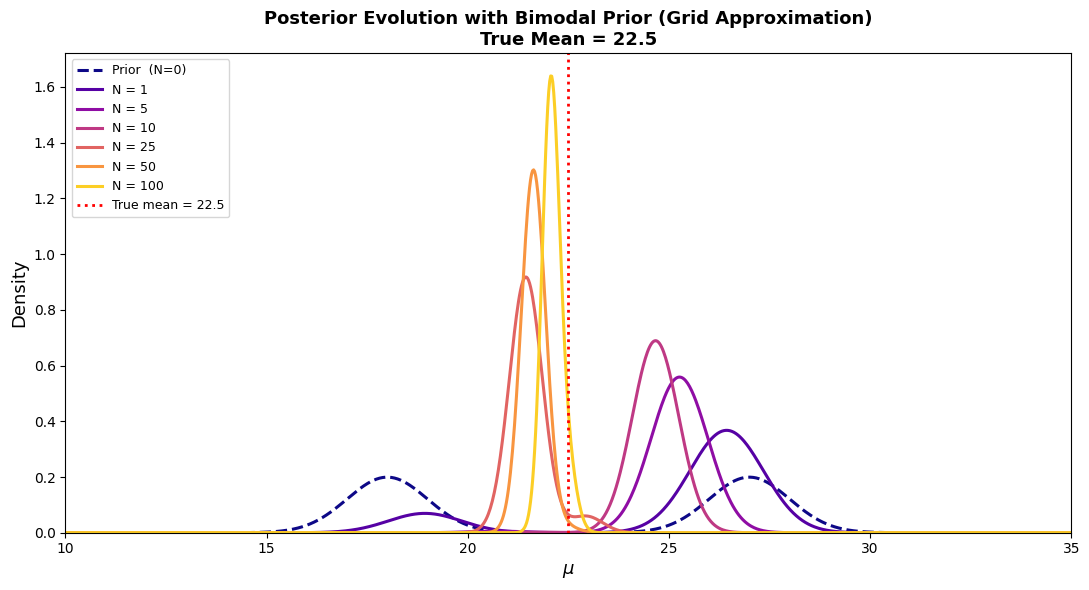

In [12]:
plot_steps = [0, 1, 5, 10, 25, 50, 100]
colors     = plt.cm.plasma(np.linspace(0, 0.9, len(plot_steps)))

fig, ax = plt.subplots(figsize=(11, 6))

# Plot the prior (N=0)
prior_vals = bimodal_prior(mu_grid)
prior_norm = prior_vals / np.trapz(prior_vals, mu_grid)
ax.plot(mu_grid, prior_norm, color=colors[0], lw=2.2,
        linestyle='--', label='Prior  (N=0)')

# Plot posterior at each step
for idx, n in enumerate(plot_steps[1:], 1):
    post = grid_posterior(mu_grid, bimodal_prior, data_100[:n], sigma2)
    ax.plot(mu_grid, post, color=colors[idx], lw=2.2, label=f'N = {n}')

ax.axvline(mu_true, color='red', lw=2, linestyle=':', label=f'True mean = {mu_true}')

ax.set_xlabel(r'$\mu$', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Posterior Evolution with Bimodal Prior (Grid Approximation)\nTrue Mean = 22.5',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(10, 35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

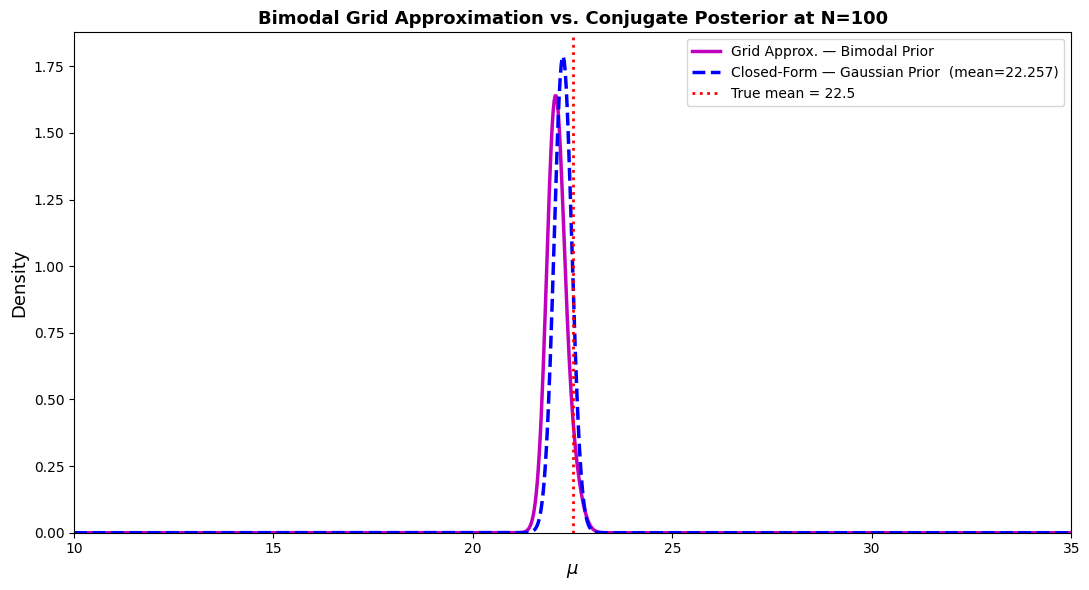

In [13]:
# Gaussian posterior function from Part 2 (redefine here if running standalone)
def gaussian_posterior(mu_0, sigma2_0, sigma2, data_subset):
    N = len(data_subset)
    if N == 0:
        return mu_0, sigma2_0
    x_bar    = data_subset.mean()
    sigma2_N = 1.0 / (1.0/sigma2_0 + N/sigma2)
    mu_N     = sigma2_N * (mu_0/sigma2_0 + N*x_bar/sigma2)
    return mu_N, sigma2_N


# Bimodal grid posterior at N=100
post_bimodal = grid_posterior(mu_grid, bimodal_prior, data_100, sigma2)

# Closed-form conjugate posterior at N=100
mu_cf, sigma2_cf = gaussian_posterior(mu_0, sigma2_0, sigma2, data_100)
post_conj        = norm.pdf(mu_grid, mu_cf, np.sqrt(sigma2_cf))

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(mu_grid, post_bimodal, 'm-',  lw=2.5, label='Grid Approx. — Bimodal Prior')
ax.plot(mu_grid, post_conj,    'b--', lw=2.5, label=f'Closed-Form — Gaussian Prior  (mean={mu_cf:.3f})')
ax.axvline(mu_true, color='red', lw=2, linestyle=':', label=f'True mean = {mu_true}')

ax.set_xlabel(r'$\mu$', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Bimodal Grid Approximation vs. Conjugate Posterior at N=100',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(10, 35)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [14]:
# ──────────────────────────────────────────────
# Method 1 : Grid Approximation (Bimodal Prior)
# ──────────────────────────────────────────────
tracemalloc.start()
t0 = time.perf_counter()

post_grid_1000 = grid_posterior(mu_grid, bimodal_prior, data_1000, sigma2)

t1 = time.perf_counter()
_, peak_grid = tracemalloc.get_traced_memory()
tracemalloc.stop()

time_grid   = t1 - t0
memory_grid = peak_grid / 1024          # convert bytes → KB

# ──────────────────────────────────────────────
# Method 2 : Closed-Form Conjugate Update
# ──────────────────────────────────────────────
tracemalloc.start()
t2 = time.perf_counter()

mu_cf_1000, sigma2_cf_1000 = gaussian_posterior(mu_0, sigma2_0, sigma2, data_1000)

t3 = time.perf_counter()
_, peak_cf = tracemalloc.get_traced_memory()
tracemalloc.stop()

time_cf   = t3 - t2
memory_cf = peak_cf / 1024              # convert bytes → KB

# ──────────────────────────────────────────────
# Print Results
# ──────────────────────────────────────────────
print("=" * 58)
print(f"  Performance Comparison  (N = 1000 data points)")
print("=" * 58)
print(f"  {'Method':<32} {'Time (s)':>10} {'Memory (KB)':>12}")
print("-" * 58)
print(f"  {'Grid Approx. (Bimodal Prior)':<32} {time_grid:>10.6f} {memory_grid:>12.2f}")
print(f"  {'Closed-Form (Gaussian Prior)':<32} {time_cf:>10.6f} {memory_cf:>12.2f}")
print("=" * 58)
print(f"\n  Grid is ~{time_grid/max(time_cf,1e-9):.1f}x slower")
print(f"  Grid uses ~{memory_grid/max(memory_cf,1e-9):.1f}x more memory")

  Performance Comparison  (N = 1000 data points)
  Method                             Time (s)  Memory (KB)
----------------------------------------------------------
  Grid Approx. (Bimodal Prior)       1.034145       206.15
  Closed-Form (Gaussian Prior)       0.003163        19.58

  Grid is ~327.0x slower
  Grid uses ~10.5x more memory


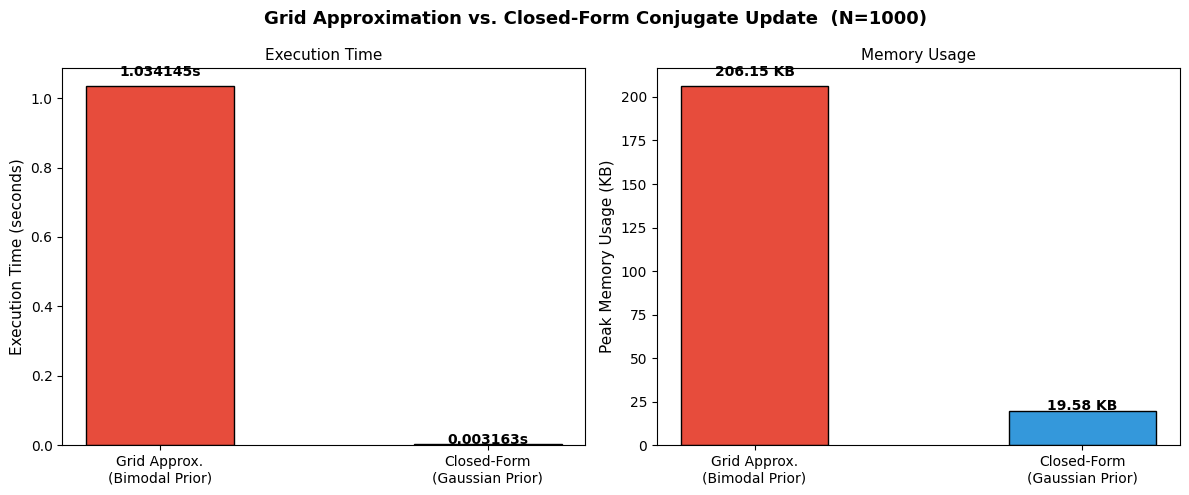

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Grid Approximation vs. Closed-Form Conjugate Update  (N=1000)',
             fontsize=13, fontweight='bold')

methods    = ['Grid Approx.\n(Bimodal Prior)', 'Closed-Form\n(Gaussian Prior)']
times      = [time_grid, time_cf]
mems       = [memory_grid, memory_cf]
bar_colors = ['#e74c3c', '#3498db']

# Time bar
axes[0].bar(methods, times, color=bar_colors, edgecolor='black', width=0.45)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)
axes[0].set_title('Execution Time', fontsize=11)
for i, v in enumerate(times):
    axes[0].text(i, v * 1.03, f'{v:.6f}s', ha='center', fontsize=10, fontweight='bold')

# Memory bar
axes[1].bar(methods, mems, color=bar_colors, edgecolor='black', width=0.45)
axes[1].set_ylabel('Peak Memory Usage (KB)', fontsize=11)
axes[1].set_title('Memory Usage', fontsize=11)
for i, v in enumerate(mems):
    axes[1].text(i, v * 1.03, f'{v:.2f} KB', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Observations — Part 3

1. **Bimodal prior behaviour:** At small N the posterior is bimodal,
   reflecting genuine uncertainty about which mode (μ≈18 or μ≈27)
   contains the truth. As more Gaussian data arrives centred near 22.5,
   the peak near the true mean grows and the other mode fades away.
   By N=100 the posterior is essentially unimodal near 22.5.

2. **Both methods agree at large N:** Despite very different priors,
   both posteriors converge to roughly the same location for large N
   — the likelihood dominates and washes out prior differences.

3. **Grid is significantly slower:** The grid approximation loops over
   all N data points × all 1000 grid points, making it O(N × G).
   The closed-form update is just arithmetic on two scalars — O(1)
   per new observation regardless of N.

4. **Curse of dimensionality:** If μ were D-dimensional, the grid
   would need G^D points. For G=1000 and D=2 that is already 1 million
   points. Conjugacy completely avoids this explosion.

5. **Why conjugacy matters:** Conjugate priors give:
   ✓ Exact posteriors (no discretization error)
   ✓ O(1) compute per update
   ✓ No memory overhead
   ✓ Perfect scalability with N and D
   Non-conjugate priors require numerical methods (grid, MCMC,
   variational inference) that are approximate and scale poorly.

## Viva Prep Questions

──────────────────────────────────────────────────────────────
Q1: If your prior in Part 1 is Beta(0, 0), what happens?
    Is this a valid probability distribution?
──────────────────────────────────────────────────────────────

Beta(α, β) requires α > 0 and β > 0. With α = β = 0:

    p(θ) ∝ θ^(0-1) (1-θ)^(0-1) = θ⁻¹ (1-θ)⁻¹

This diverges at θ=0 and θ=1. Its integral over [0,1] is infinite
→ it CANNOT be normalized → NOT a valid probability distribution.

Beta(0,0) is called Haldane's prior — an improper prior.
The posterior Beta(0+X, 0+N-X) is proper only if X > 0 AND N-X > 0
(at least one click and one non-click observed). If all observations
are the same (e.g. all clicks), the posterior is also improper.

──────────────────────────────────────────────────────────────
Q2: What happens to the posterior mean if σ₀² → ∞?
──────────────────────────────────────────────────────────────

Posterior mean formula:
    μ_N = σ_N² · (μ₀/σ₀² + N·x̄/σ²)

As σ₀² → ∞:
  • Prior precision  1/σ₀² → 0   (prior contributes nothing)
  • Posterior precision  1/σ_N² = 1/σ₀² + N/σ²  →  N/σ²
  • So  σ_N² → σ²/N
  • The term μ₀/σ₀² → 0, leaving:

        μ_N → (σ²/N) · (N·x̄/σ²) = x̄

Conclusion: With an infinitely vague prior the posterior mean
converges to the sample mean x̄ — the Maximum Likelihood Estimate.
Bayesian inference reduces to classical MLE when the prior carries
zero information.

──────────────────────────────────────────────────────────────
Q3: How do conjugate priors act as pseudo-observations?
──────────────────────────────────────────────────────────────

In the Beta-Binomial model:
    α_post = α_prior + X
    β_post = β_prior + (N - X)

α_prior and β_prior add directly to the click and non-click counts
— exactly as if we had already observed α_prior clicks and β_prior
non-clicks before the real experiment began.

Example: Beta(10, 1) = "I already saw 10 clicks and 1 non-click."
         Beta(1, 1)  = "I already saw 1 click and 1 non-click." (neutral)

Same idea in the Gaussian case: the prior precision 1/σ₀² acts like
the precision from σ²/σ₀² virtual past observations supporting μ₀.
A tight prior (small σ₀²) means many virtual observations → harder
for real data to move the posterior away from μ₀.

This makes it easy to reason about prior strength:
"How many real data points would it take to overcome this prior?"
Answer: roughly α_prior + β_prior data points in the Beta case.